In [1]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Literal, Optional

import os
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from dask.distributed import Client
from pystac_client import Client as STAC_Client
import stackstac
import rioxarray

#surpress warnings for clean notebook
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.ERROR)

Mode = Literal["local", "remote", "gateway"]

#Dask Configuration
@dataclass
class DaskConfig:
    mode: Mode = "local"
    scheduler_address: Optional[str] = None
    # dask-gateway (if used)
    gateway_url: Optional[str] = None
    gateway_proxy_address: Optional[str] = None
    cluster_options: dict = None
    #numeber of workers, threads, memory limit, etc can be set via cluster_options or env vars
    n_workers: int = 4
    # threads_per_worker: int = 2
    memory_limit: str = "8GB"

def get_client(cfg: DaskConfig) -> Client:
    if cfg.mode == "local":
        return Client(n_workers=cfg.n_workers, memory_limit=cfg.memory_limit)  # or Client(n_workers=4, threads_per_worker=2, memory_limit="8GB")

    if cfg.mode == "remote":
        if not cfg.scheduler_address: # remote scheduler (e.g. tcp://scheduler:8786 or tls://...)
            raise ValueError("scheduler_address is required for mode='remote'")
        return Client(cfg.scheduler_address)

    if cfg.mode == "gateway":
        from dask_gateway import Gateway
        gw = Gateway(address=cfg.gateway_url) if cfg.gateway_url else Gateway()
        cluster_kwargs = {}
        if cfg.cluster_options:
            # If you’ve defined custom options server-side, pass them here
            cluster_kwargs.update(cfg.cluster_options)
        cluster = gw.new_cluster(**cluster_kwargs)
        # (Optional) scale workers
        cluster.scale(4)  # tune for your workload
        client = cluster.get_client()  # auto-connect via gateway’s proxy
        print("Gateway dashboard:", cluster.dashboard_link)
        return client

    raise ValueError(f"Unknown mode: {cfg.mode}")

# Select how to connect to Dask
dask_cfg = DaskConfig(
    mode=os.environ.get("DASK_MODE", "local"),                 # "local" | "remote" | "gateway"
    scheduler_address=os.environ.get("DASK_SCHEDULER"),        # for "remote"
    gateway_url=os.environ.get("DASK_GATEWAY_URL"),
    n_workers= 4,
    # memory_limit='8GB'

)
client = get_client(dask_cfg)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 29.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57388,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:57400,Total threads: 4
Dashboard: http://127.0.0.1:57403/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:57391,


In [2]:
#STAC Catalogue
catalog = STAC_Client.open("https://stac.sage.uvt.ro/")
catalog


<Client id=stac-fastapi>

In [3]:
#Timisoara AOI
AOI = (21.10, 45.65, 21.40, 45.85)
#Romania AOI
# AOI = (20.2201924985, 43.6884447292, 29.62654341, 48.2208812526)
search = catalog.search(
    collections=["sentinel-2-l1c"],
    bbox=AOI, #(20.2201924985, 43.6884447292, 29.62654341, 48.2208812526),
    datetime="2021-06-01/2021-06-20",
    query=["eo:cloud_cover<5"]#{"eo:cloud_cover": {"lt": 50}},  # L1C uses metadata cloud cover; we’ll also apply fmask
)
items = list(search.get_items())
if not items:
    raise RuntimeError("No STAC items found for your query.")
print(f"Found {len(items)} items.")

Found 5 items.


In [4]:
#get only the first item for testing
# items = items[:1]

In [5]:
#compute the data cube
assets = ["B04", "B08", "fmask"]


arr = stackstac.stack(
    items,
    assets=assets,
    epsg=32634,
    resolution=10,                               # 10 m
    # chunks={"time": 1, "x": 2048, "y": 2048},    # tune for your cluster
    # dtype={"B04": "uint16", "B08": "uint16", "fmask": "uint8"},
    fill_value=0,
    # resampling="bilinear",
    bounds_latlon=AOI,  # clip to AOI
).rename("raw")
#chunk
arr = arr.chunk({"time": 1, "x": 2048, "y": 2048})


In [6]:
# Convert bands to variables
ds = arr.to_dataset(dim="band")
ds

<xarray.Dataset> Size: 626MB
Dimensions:                          (time: 5, y: 2230, x: 2341, band: 3)
Coordinates: (12/28)
  * time                             (time) datetime64[ns] 40B 2021-06-03T10:...
    id                               (time) <U60 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    platform                         (time) <U11 220B dask.array<chunksize=(1,), meta=np.ndarray>
    s2:product_uri                   (time) <U65 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    s2:datatake_id                   (time) <U34 680B dask.array<chunksize=(1,), meta=np.ndarray>
    eo:cloud_cover                   (time) float64 40B dask.array<chunksize=(1,), meta=np.ndarray>
    ...                               ...
    s2:degraded_msi_data_percentage  float64 8B 0.0
    s2:processing_baseline           <U5 20B '03.00'
    instruments                      <U3 12B 'msi'
    s2:datatake_type                 <U8 32B 'INS-NOBS'
    proj:code                        <U10 40B 'EPSG:32634'
    epsg                             int64 8B 32634
Dimensions without coordinates: band
Data variables:
    B04                              (time, y, x) float64 209MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    B08                              (time, y, x) float64 209MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    fmask                            (time, y, x) float64 209MB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    spec:        RasterSpec(epsg=32634, bounds=(507760, 5055160, 531170, 5077...
    crs:         epsg:32634
    transform:   | 10.00, 0.00, 507760.00|\n| 0.00,-10.00, 5077460.00|\n| 0.0...
    resolution:  10

In [7]:
#scale data sentinel 2 l1c
scale = 1 / 10000.0
red = ds["B04"].astype("float32") * scale
nir = ds["B08"].astype("float32") * scale

In [8]:
# Basic validity
valid_reflectance = (red > 0) & (nir > 0) & np.isfinite(red) & np.isfinite(nir)


In [9]:
bad_fmask = xr.DataArray([2, 3, 4], dims=["classes"])
if "fmask" in ds:
    cloud_ok = ~ds["fmask"].isin(bad_fmask)
else:
    cloud_ok = xr.ones_like(red, dtype=bool)

valid = valid_reflectance & cloud_ok

In [10]:
eps = 1e-6
ndvi = (nir - red) / xr.where((nir + red) == 0, eps, (nir + red))
ndvi = ndvi.where(valid)

In [11]:
ndvi_median = ndvi.median(dim="time", skipna=True).astype("float32")

In [12]:
# Attach spatial metadata for plotting/writing
# ndvi_median = ndvi_median.rio.write_crs(arr.geobox.crs)
# ndvi_median = ndvi_median.rio.write_transform(arr.geobox.transform)

/Users/gabriel/anaconda3/envs/mlenv/lib/python3.12/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


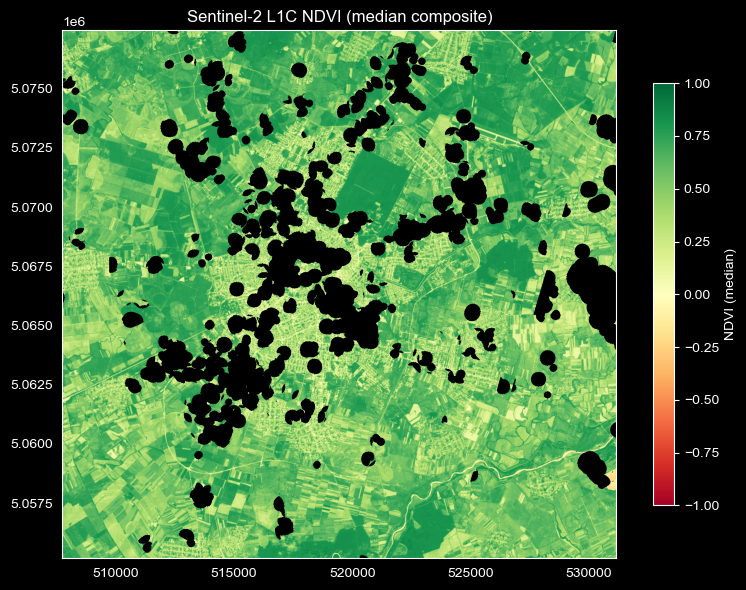

In [13]:
minx, miny, maxx, maxy = ndvi_median.rio.bounds()
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
im = ax.imshow(
    ndvi_median.compute(),       # trigger compute for the composite only
    extent=(minx, maxx, miny, maxy),
    origin="upper",
    cmap="RdYlGn",
    vmin=-1.0, vmax=1.0,
)
cb = plt.colorbar(im, ax=ax, shrink=0.8, label="NDVI (median)")
ax.set_title("Sentinel-2 L1C NDVI (median composite)")
# ax.set_xlabel(f"Longitude / {ndvi_median.rio.crs.to_string()}")
# ax.set_ylabel("Latitude")
plt.tight_layout()
plt.grid(visible=False)
plt.show()

In [14]:
import rasterio

url = "https://storage.info.uvt.ro/eodata/Sentinel-2/2025/4/6/T35TPM/S2A_MSIL1C_20250406T091321_N0511_R050_T35TPM_20250406T160028.SAFE/GRANULE/L1C_T35TPM_A051127_20250406T091323/IMG_DATA/T35TPM_20250406T091321_B02.tif"
with rasterio.open(url) as src:
    window = src.read(1, window=((1000, 2000), (1000, 2000)))

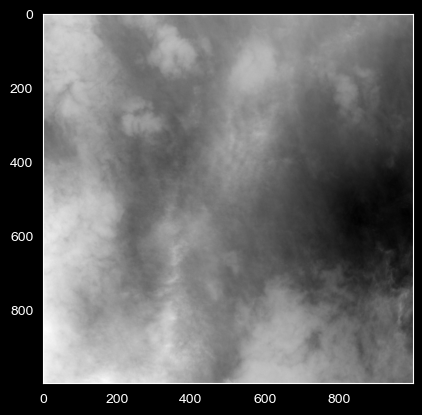

In [15]:
plt.imshow(window, cmap="gray")
plt.grid(visible=False)